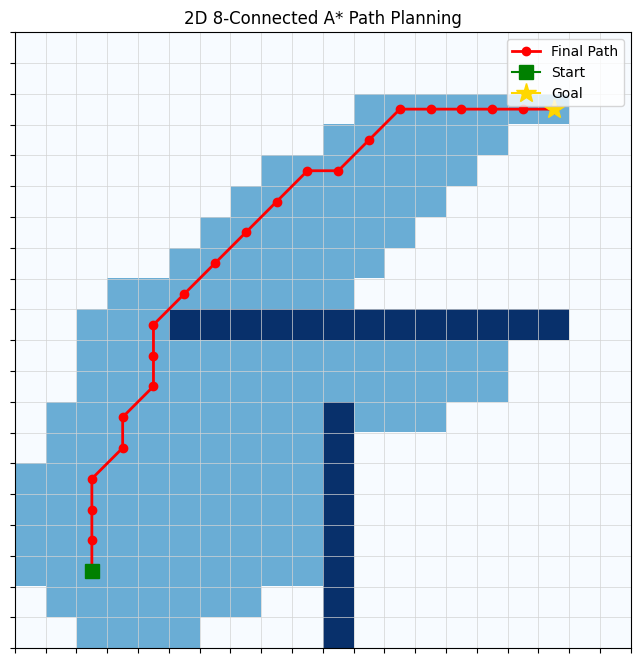

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

class Node:
    """A node class for A* Pathfinding"""
    def __init__(self, parent=None, position=None):
        self.parent = parent
        self.position = position
        
        self.g = 0 # Cost from start to current node
        self.h = 0 # Estimated cost from current node to goal
        self.f = 0 # Total cost (g + h)

    def __eq__(self, other):
        return self.position == other.position
    
    def __lt__(self, other):
        return self.f < other.f

def get_heuristic(current, goal):
    """Calculate the Euclidean distance heuristic."""
    return np.sqrt((current[0] - goal[0])**2 + (current[1] - goal[1])**2)

def astar(grid_size, start, goal, obstacles):
    """
    Executes the A* pathfinding algorithm.
    Returns the path as a list of tuples and a set of all explored nodes.
    """
    # Create start and goal nodes
    start_node = Node(None, start)
    goal_node = Node(None, goal)

    # Initialize open and closed lists
    open_list = []
    closed_set = set()
    
    # Heapify the open_list and add the start node
    heapq.heappush(open_list, (start_node.f, start_node))
    
    # 8-connected grid movements (dx, dy, cost)
    movements = [
        (0, -1, 1), (0, 1, 1), (-1, 0, 1), (1, 0, 1),          # Orthogonal
        (-1, -1, 1.414), (-1, 1, 1.414), (1, -1, 1.414), (1, 1, 1.414) # Diagonal
    ]

    explored_nodes = [] # To keep track of visualization order

    while len(open_list) > 0:
        # Get the current node (node with the lowest f cost)
        current_node = heapq.heappop(open_list)[1]
        
        # Add current node to closed list
        closed_set.add(current_node.position)
        explored_nodes.append(current_node.position)

        # Check if we found the goal
        if current_node == goal_node:
            path = []
            current = current_node
            while current is not None:
                path.append(current.position)
                current = current.parent
            return path[::-1], explored_nodes # Return reversed path and explored nodes

        # Generate children
        for move in movements:
            node_position = (current_node.position[0] + move[0], current_node.position[1] + move[1])
            
            # Make sure within range (Grid boundaries)
            if node_position[0] > (grid_size[0] - 1) or node_position[0] < 0 or \
               node_position[1] > (grid_size[1] - 1) or node_position[1] < 0:
                continue
                
            # Make sure walkable (Not an obstacle)
            if node_position in obstacles:
                continue
                
            # Make sure it isn't already explored
            if node_position in closed_set:
                continue

            # Create new node
            new_node = Node(current_node, node_position)
            
            # Calculate f, g, and h costs
            new_node.g = current_node.g + move[2]
            new_node.h = get_heuristic(new_node.position, goal_node.position)
            new_node.f = new_node.g + new_node.h
            
            # Add child to open list if a cheaper path doesn't already exist there
            # (Simplified for clarity: just pushing it to the heap)
            heapq.heappush(open_list, (new_node.f, new_node))
            
    return None, explored_nodes # No path found

def visualize_planner(grid_size, start, goal, obstacles, path, explored_nodes):
    """Visualizes the grid, obstacles, explored nodes, and final path."""
    # Create an empty grid
    grid = np.zeros(grid_size)
    
    # Plot Explored Nodes (Light Blue)
    for x, y in explored_nodes:
        grid[x][y] = 0.5 
        
    # Plot Obstacles (Black)
    for x, y in obstacles:
        grid[x][y] = 1.0 
        
    # Set up the plot
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.T, cmap='Blues', origin='lower') # .T transposes for standard x,y plotting
    
    # Plot the final path
    if path:
        path_x = [p[0] for p in path]
        path_y = [p[1] for p in path]
        plt.plot(path_x, path_y, marker='o', color='red', linewidth=2, label='Final Path')
    
    # Mark start and goal
    plt.plot(start[0], start[1], marker='s', color='green', markersize=10, label='Start')
    plt.plot(goal[0], goal[1], marker='*', color='gold', markersize=15, label='Goal')
    
    plt.grid(True, which='both', color='lightgrey', linewidth=0.5)
    plt.xticks(np.arange(-0.5, grid_size[0], 1), [])
    plt.yticks(np.arange(-0.5, grid_size[1], 1), [])
    plt.title('2D 8-Connected A* Path Planning')
    plt.legend()
    plt.show()

# ==========================================
# USER CONFIGURATION (Execution Block)
# ==========================================
grid_size = (20, 20)
start_pos = (2, 2)
goal_pos = (17, 17)
# Defining some arbitrary static obstacles
obstacle_list = [(x, 10) for x in range(5, 18)] + [(10, y) for y in range(0, 8)]

# Run the algorithm
final_path, explored = astar(grid_size, start_pos, goal_pos, obstacle_list)

# Visualize the result
visualize_planner(grid_size, start_pos, goal_pos, obstacle_list, final_path, explored)

In [ ]:
#  code for the part E : 

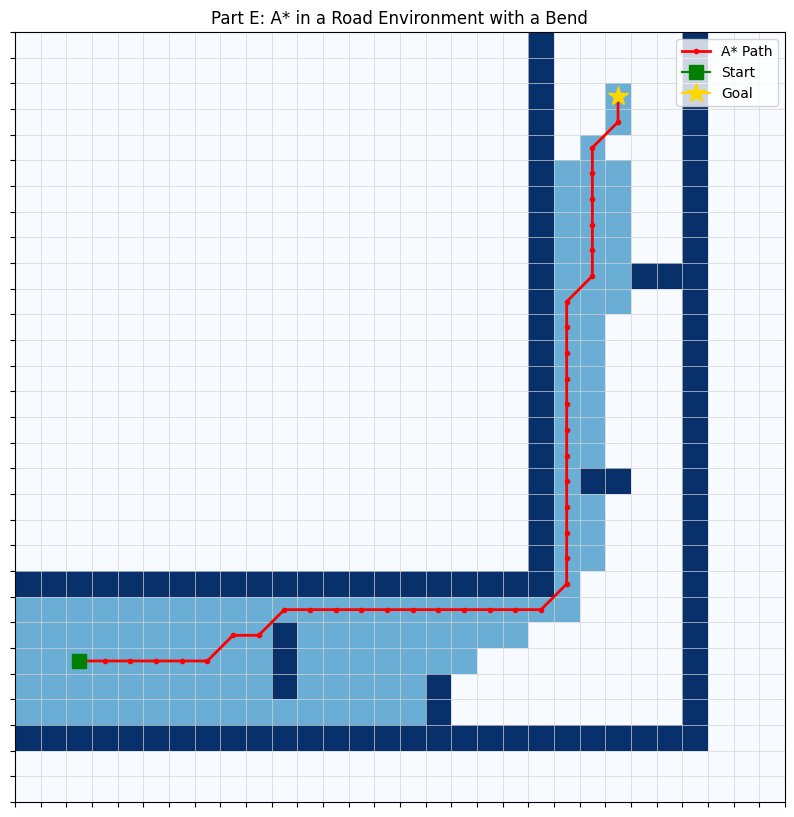

In [5]:
# ==========================================
# PART E: Road-Like Environment (Isolated)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

grid_size = (30, 30)
start_pos = (2, 5)
goal_pos = (23, 27)

obstacles_e = set()

# 1. Build the "Road" Boundaries to form a continuous 90-degree left bend
# Inner Boundary (Bottom edge and Right edge of the bend)
for x in range(0, 27): obstacles_e.add((x, 2))
for y in range(2, 30): obstacles_e.add((26, y))

# Outer Boundary (Top edge and Left edge of the bend)
for x in range(0, 21): obstacles_e.add((x, 8))
for y in range(8, 30): obstacles_e.add((20, y))

# 2. Add 4 Static Obstacles to force the algorithm to weave
obstacles_e.update([(10, 4), (10, 5), (10, 6)]) # Obstacle 1: Mid-lane horizontal
obstacles_e.update([(16, 3), (16, 4)])          # Obstacle 2: Bottom-lane horizontal
obstacles_e.update([(22, 12), (23, 12)])        # Obstacle 3: Left-lane vertical
obstacles_e.update([(24, 20), (25, 20)])        # Obstacle 4: Right-lane vertical

# 3. Run the A* algorithm on the connected map
final_path_e, explored_e = astar(grid_size, start_pos, goal_pos, list(obstacles_e))

# ==========================================
# Visualization Engine for Part E Only
# ==========================================
def visualize_part_e(grid_size, start, goal, obstacles, path, explored):
    grid = np.zeros(grid_size)
    
    # Plot Explored Nodes
    for x, y in explored: 
        grid[x][y] = 0.5 
        
    # Plot Obstacles
    for x, y in obstacles: 
        grid[x][y] = 1.0 
        
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.T, cmap='Blues', origin='lower') 
    
    # Plot the final path
    if path:
        path_x = [p[0] for p in path]
        path_y = [p[1] for p in path]
        plt.plot(path_x, path_y, marker='.', color='red', linewidth=2, label='A* Path')
    
    # Mark start and goal
    plt.plot(start[0], start[1], marker='s', color='green', markersize=10, label='Start')
    plt.plot(goal[0], goal[1], marker='*', color='gold', markersize=15, label='Goal')
    
    plt.grid(True, which='both', color='lightgrey', linewidth=0.5)
    plt.xticks(np.arange(-0.5, grid_size[0], 1), [])
    plt.yticks(np.arange(-0.5, grid_size[1], 1), [])
    plt.title('Part E: A* in a Road Environment with a Bend')
    plt.legend()
    plt.show()

# Render the plot
visualize_part_e(grid_size, start_pos, goal_pos, list(obstacles_e), final_path_e, explored_e)

code for the part F : 

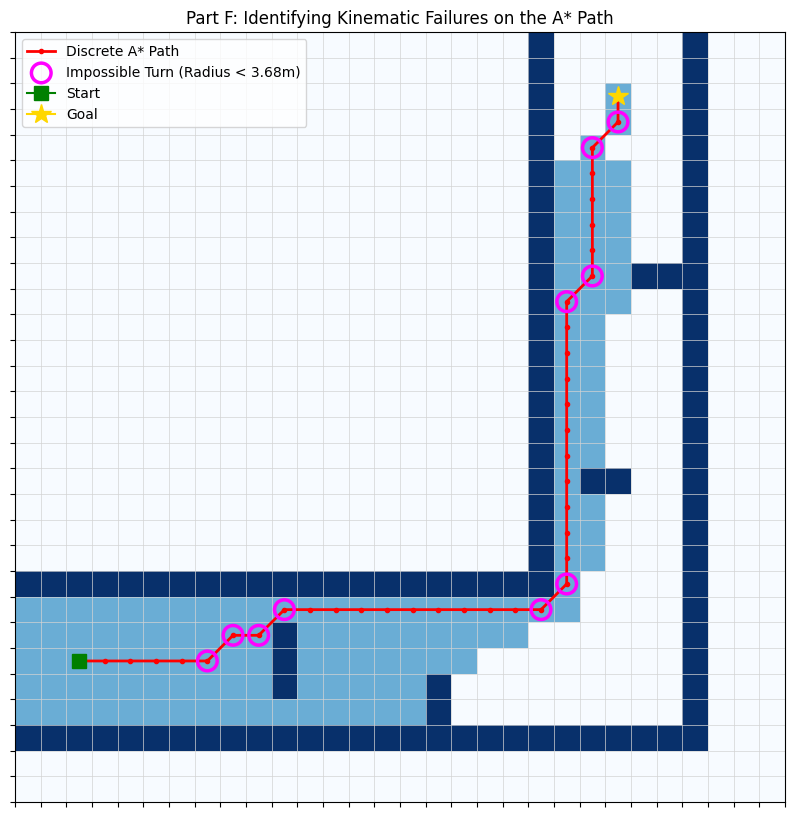

In [6]:
# ==========================================
# PART F: Checking the Minimum Turning Radius
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

def mark_impossible_turns(path, min_radius=3.68):
    """
    Checks the path for sharp turns that violate the buggy's minimum turning radius.
    In a standard 1x1m 8-connected grid, any heading change of 45 or 90 degrees
    represents an instantaneous turn (radius = 0m), which violates a 3.68m limit.
    """
    impossible_nodes = []
    
    if not path or len(path) < 3:
        return impossible_nodes
        
    for i in range(1, len(path) - 1):
        p1 = np.array(path[i-1])
        p2 = np.array(path[i])   # The turning point
        p3 = np.array(path[i+1])
        
        # Calculate movement vectors entering and exiting the node
        v1 = p2 - p1
        v2 = p3 - p2
        
        # Calculate heading change between the two vectors
        dot_product = np.dot(v1, v2)
        norm_v1 = np.linalg.norm(v1)
        norm_v2 = np.linalg.norm(v2)
        
        cos_angle = dot_product / (norm_v1 * norm_v2)
        cos_angle = np.clip(cos_angle, -1.0, 1.0)
        angle_deg = np.degrees(np.arccos(cos_angle))
        
        # If the vehicle changes heading (angle > 1 degree to account for float math),
        # it is pivoting in place. This is physically impossible for a buggy.
        if angle_deg > 1.0: 
            impossible_nodes.append(path[i])
            
    return impossible_nodes

# Calculate the impossible turns using the 3.68m radius calculated in Part (b)
bad_turns = mark_impossible_turns(final_path_e, 3.68)

# ==========================================
# Visualization Engine for Part F
# ==========================================
def visualize_part_f(grid_size, start, goal, obstacles, path, explored, bad_turns):
    grid = np.zeros(grid_size)
    
    for x, y in explored: 
        grid[x][y] = 0.5 
    for x, y in obstacles: 
        grid[x][y] = 1.0 
        
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.T, cmap='Blues', origin='lower') 
    
    if path:
        path_x = [p[0] for p in path]
        path_y = [p[1] for p in path]
        plt.plot(path_x, path_y, marker='.', color='red', linewidth=2, label='Discrete A* Path')
    
    # Mark the impossible turns with large magenta circles
    if bad_turns:
        bad_x = [p[0] for p in bad_turns]
        bad_y = [p[1] for p in bad_turns]
        plt.scatter(bad_x, bad_y, facecolors='none', edgecolors='magenta', s=200, 
                    linewidths=2.5, zorder=5, label='Impossible Turn (Radius < 3.68m)')
    
    plt.plot(start[0], start[1], marker='s', color='green', markersize=10, label='Start')
    plt.plot(goal[0], goal[1], marker='*', color='gold', markersize=15, label='Goal')
    
    plt.grid(True, which='both', color='lightgrey', linewidth=0.5)
    plt.xticks(np.arange(-0.5, grid_size[0], 1), [])
    plt.yticks(np.arange(-0.5, grid_size[1], 1), [])
    plt.title('Part F: Identifying Kinematic Failures on the A* Path')
    plt.legend()
    plt.show()

# Render the plot using the variables from Part E
visualize_part_f(grid_size, start_pos, goal_pos, list(obstacles_e), final_path_e, explored_e, bad_turns)